In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)

# %% Load all available results

results_dir = Path('results')
available_levels = []
level_data = {}

# Try to load each level
for level_file in ['level1_baseline_rag.json', 'level2_semantic_merged.json', 'level3_events.json', 'level4_triview.json']:
    if (results_dir / level_file).exists():
        with open(results_dir / level_file, 'r') as f:
            data = json.load(f)
            level_name = data['level']
            level_data[level_name] = data
            available_levels.append(level_name)
            print(f"Loaded {level_name}")

print(f"\nTotal levels loaded: {len(available_levels)}")

Loaded level1_baseline_rag
Loaded level2_semantic_merged
Loaded level3_events
Loaded level4_triview

Total levels loaded: 4


# Visualizations

In [3]:
def create_comparison_df(metric='accuracy'):
    """Create dataframe for cross-level comparison"""
    rows = []
    
    for level_name, data in level_data.items():
        # Overall
        rows.append({
            'Level': level_name,
            'Category': 'Overall',
            'Value': data[metric]
        })
        
        # By duration
        for duration in ['short', 'medium', 'long']:
            rows.append({
                'Level': level_name,
                'Category': f'{duration.capitalize()}',
                'Value': data['duration_stats'][duration][metric]
            })
    
    return pd.DataFrame(rows)

def create_task_comparison_df():
    """Create dataframe for task type comparison across levels"""
    all_tasks = set()
    for data in level_data.values():
        all_tasks.update(data['task_type_stats'].keys())
    
    rows = []
    for level_name, data in level_data.items():
        for task in all_tasks:
            if task in data['task_type_stats']:
                rows.append({
                    'Level': level_name,
                    'Task': task,
                    'Accuracy': data['task_type_stats'][task]['accuracy'],
                    'Count': data['task_type_stats'][task]['total']
                })
    
    return pd.DataFrame(rows)

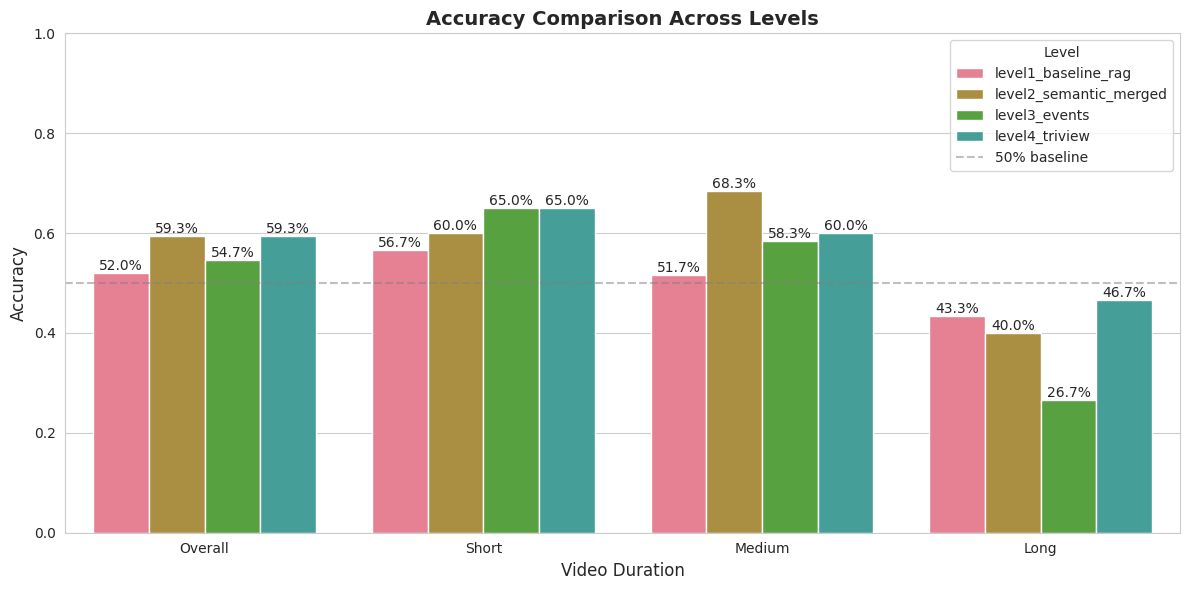

✓ Saved: accuracy_comparison_all.png


/tmp/ipykernel_15761/3934658346.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{task} (n={task_counts[task]})" for task in task_order], rotation=45, ha='right')


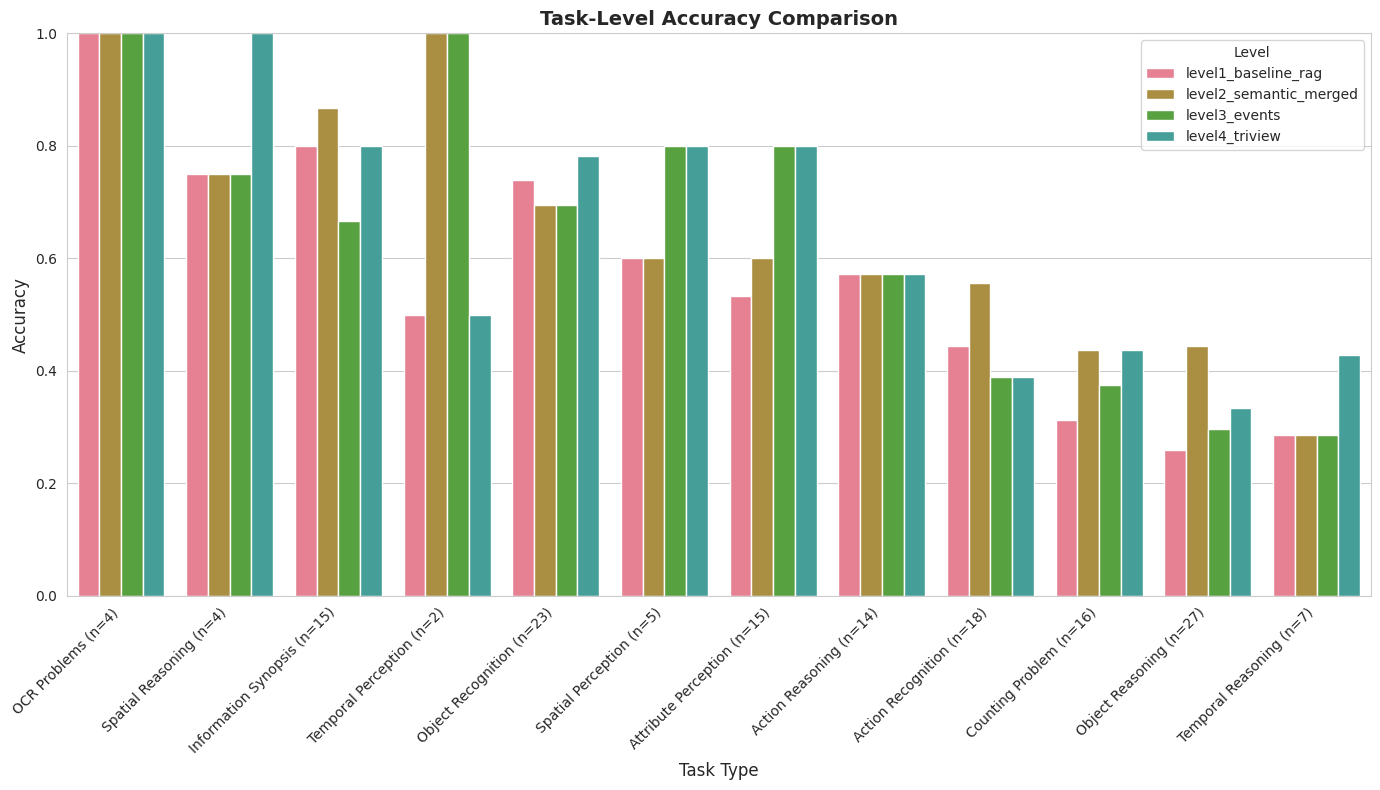

Saved: task_accuracy_comparison.png


In [7]:
# %% 1. ACCURACY COMPARISON PLOTS

# 1a. Overall + Duration Accuracy (Bar Chart)
fig, ax = plt.subplots(figsize=(12, 6))

df = create_comparison_df('accuracy')
categories = ['Overall', 'Short', 'Medium', 'Long']
df['Category'] = pd.Categorical(df['Category'], categories=categories, ordered=True)

# Define level order
level_order = ['level1_baseline_rag', 'level2_semantic_merged', 'level3_events', 'level4_triview']

sns.barplot(data=df, x='Category', y='Value', hue='Level', 
            hue_order=level_order, ax=ax)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_xlabel('Video Duration', fontsize=12)
ax.set_title('Accuracy Comparison Across Levels', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='50% baseline')
ax.legend(title='Level', loc='upper right')

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', 
                 labels=[f'{v.get_height()*100:.1f}%' for v in container])

plt.tight_layout()
plt.savefig('results/accuracy_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: accuracy_comparison_all.png")

# 1b. Task Type Accuracy (Grouped Bar Chart)
task_df = create_task_comparison_df()

# Sort by average accuracy across levels
task_order = task_df.groupby('Task')['Accuracy'].mean().sort_values(ascending=False).index

# Get counts per task (assuming counts are the same across levels for each task)
task_counts = task_df.groupby('Task')['Count'].first()

fig, ax = plt.subplots(figsize=(14, 8))
task_df['Task'] = pd.Categorical(task_df['Task'], categories=task_order, ordered=True)
task_df_sorted = task_df.sort_values('Task')

# Define level order
level_order = ['level1_baseline_rag', 'level2_semantic_merged', 'level3_events', 'level4_triview']

sns.barplot(data=task_df_sorted, x='Task', y='Accuracy', hue='Level',
            hue_order=level_order, ax=ax)  # <-- Add this
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_xlabel('Task Type', fontsize=12)
ax.set_title('Task-Level Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)

# Update x-tick labels to include question counts
ax.set_xticklabels([f"{task} (n={task_counts[task]})" for task in task_order], rotation=45, ha='right')

ax.legend(title='Level')

plt.tight_layout()
plt.savefig('results/task_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: task_accuracy_comparison.png")

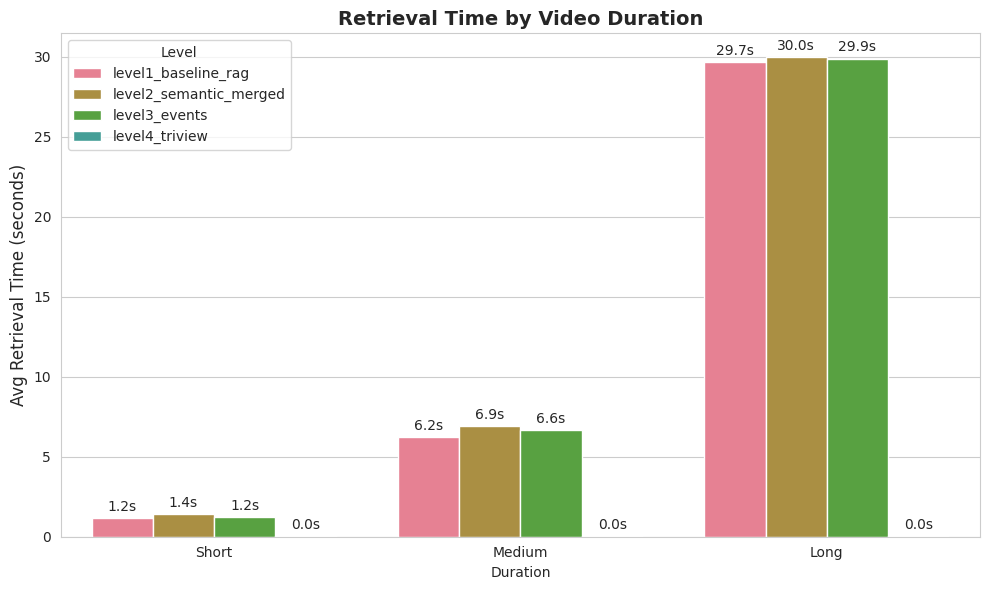

✓ Saved: retrieval_time_comparison.png


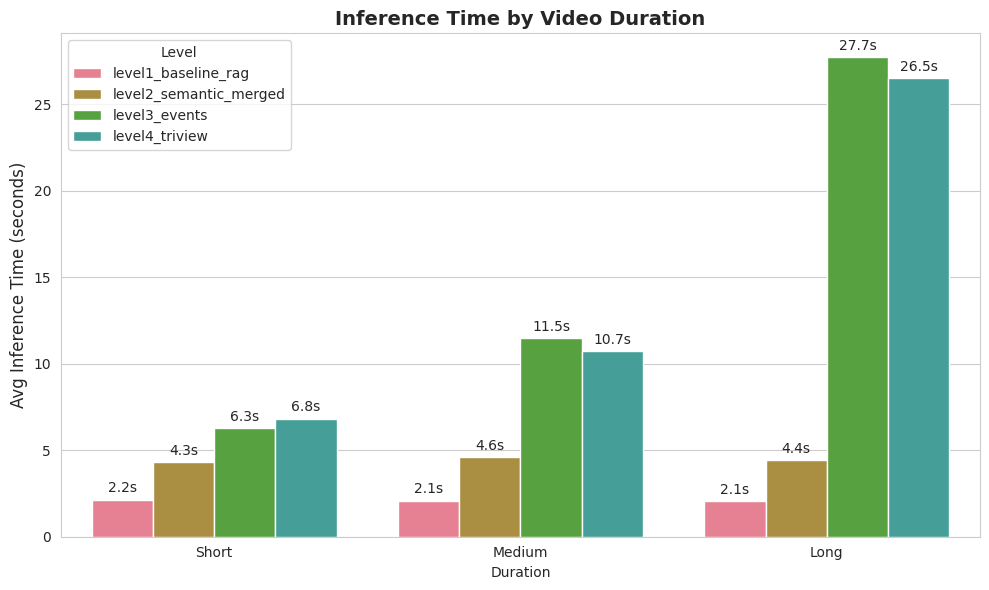

✓ Saved: inference_time_comparison.png


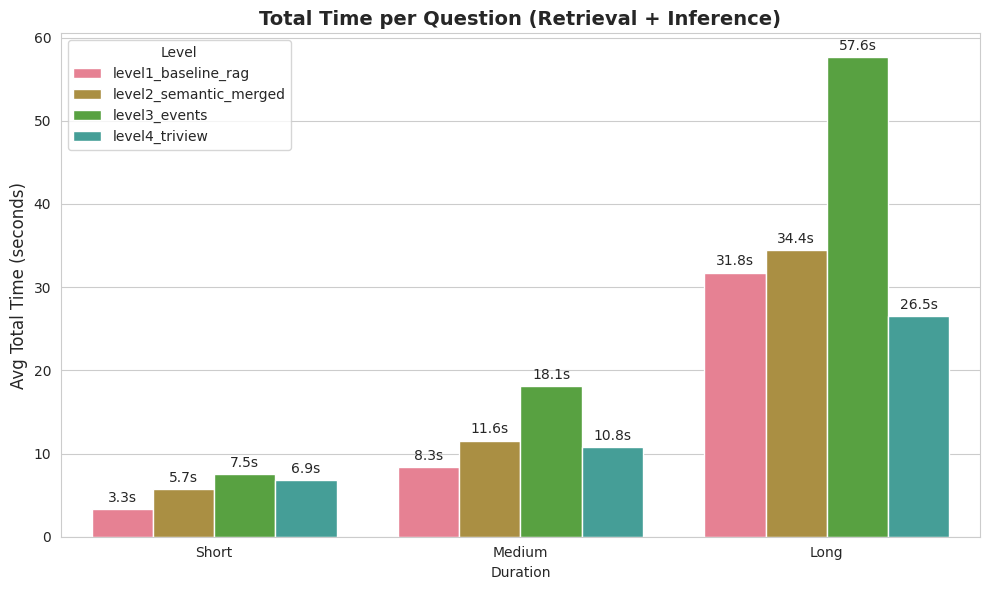

✓ Saved: total_time_comparison.png


In [ ]:
# %% 2. LATENCY COMPARISON PLOTS (with fallback computation)

def get_duration_times(data, duration):
    """Get avg times for a duration, computing from results if needed"""
    # Check if pre-computed stats exist
    if 'avg_retrieval_time' in data['duration_stats'][duration]:
        return {
            'retrieval': data['duration_stats'][duration]['avg_retrieval_time'],
            'inference': data['duration_stats'][duration]['avg_inference_time']
        }
    
    #for triview level, get retrieval time from data/triview_cache/build_summary.json
    if data['level'] == 'level4_triview':
        build_summary_path = Path('data/triview_cache/build_summary.json')
        
    
    # Otherwise compute from results
    results = [r for r in data['results'] if r['duration'] == duration]
    if not results:
        return {'retrieval': 0, 'inference': 0}
    
    return {
        'retrieval': np.mean([r['retrieval_time'] for r in results]),
        'inference': np.mean([r['inference_time'] for r in results])
    }

# 2a. Retrieval Time by Duration
fig, ax = plt.subplots(figsize=(10, 6))

retrieval_rows = []
for level_name, data in level_data.items():
    for duration in ['short', 'medium', 'long']:
        times = get_duration_times(data, duration)
        retrieval_rows.append({
            'Level': level_name,
            'Duration': duration.capitalize(),
            'Time (s)': times['retrieval']
        })

df_retrieval = pd.DataFrame(retrieval_rows)
df_retrieval['Duration'] = pd.Categorical(df_retrieval['Duration'], 
                                          categories=['Short', 'Medium', 'Long'], 
                                          ordered=True)

sns.barplot(data=df_retrieval, x='Duration', y='Time (s)', hue='Level', ax=ax)
ax.set_title('Retrieval Time by Video Duration', fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Retrieval Time (seconds)', fontsize=12)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1fs', padding=3)

plt.tight_layout()
# plt.savefig('results/retrieval_time_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: retrieval_time_comparison.png")

# 2b. Inference Time by Duration
fig, ax = plt.subplots(figsize=(10, 6))

inference_rows = []
for level_name, data in level_data.items():
    for duration in ['short', 'medium', 'long']:
        times = get_duration_times(data, duration)
        inference_rows.append({
            'Level': level_name,
            'Duration': duration.capitalize(),
            'Time (s)': times['inference']
        })

df_inference = pd.DataFrame(inference_rows)
df_inference['Duration'] = pd.Categorical(df_inference['Duration'], 
                                          categories=['Short', 'Medium', 'Long'], 
                                          ordered=True)

sns.barplot(data=df_inference, x='Duration', y='Time (s)', hue='Level', ax=ax)
ax.set_title('Inference Time by Video Duration', fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Inference Time (seconds)', fontsize=12)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1fs', padding=3)

plt.tight_layout()
# plt.savefig('results/inference_time_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: inference_time_comparison.png")

# 2c. Total Time per Question
fig, ax = plt.subplots(figsize=(10, 6))

total_rows = []
for level_name, data in level_data.items():
    for duration in ['short', 'medium', 'long']:
        times = get_duration_times(data, duration)
        total_time = times['retrieval'] + times['inference']
        total_rows.append({
            'Level': level_name,
            'Duration': duration.capitalize(),
            'Time (s)': total_time
        })

df_total = pd.DataFrame(total_rows)
df_total['Duration'] = pd.Categorical(df_total['Duration'], 
                                      categories=['Short', 'Medium', 'Long'], 
                                      ordered=True)

sns.barplot(data=df_total, x='Duration', y='Time (s)', hue='Level', ax=ax)
ax.set_title('Total Time per Question (Retrieval + Inference)', 
             fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Total Time (seconds)', fontsize=12)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1fs', padding=3)

plt.tight_layout()
# plt.savefig('results/total_time_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: total_time_comparison.png")

In [6]:
# %% 5. SUMMARY TABLE

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

summary_data = []
for level_name in available_levels:
    data = level_data[level_name]
    summary_data.append({
        'Level': level_name,
        'Overall Acc': f"{data['accuracy']:.1%}",
        'Short Acc': f"{data['duration_stats']['short']['accuracy']:.1%}",
        'Medium Acc': f"{data['duration_stats']['medium']['accuracy']:.1%}",
        'Long Acc': f"{data['duration_stats']['long']['accuracy']:.1%}",
        'Avg Time (s)': f"{data['avg_retrieval_time'] + data['avg_inference_time']:.1f}",
        'Questions': data['total_questions']
    })

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

# Save to CSV
df_summary.to_csv('results/summary_comparison.csv', index=False)
print("\n✓ Saved: summary_comparison.csv")

print("\n" + "="*80)
print("VISUALIZATION COMPLETE")
print("="*80)
print(f"\nGenerated visualizations:")
print("  - accuracy_comparison_all.png")
print("  - task_accuracy_comparison.png")
print("  - retrieval_time_comparison.png")
print("  - inference_time_comparison.png")
print("  - total_time_comparison.png")
if 'level2_semantic_merged' in level_data:
    print("  - level2_frames_used.png")
    print("  - level2_chunk_length.png")
if len(available_levels) >= 2:
    print("  - level2_vs_level1_delta.png")
print("  - summary_comparison.csv")


SUMMARY STATISTICS
                 Level Overall Acc Short Acc Medium Acc Long Acc Avg Time (s)  Questions
   level1_baseline_rag       52.0%     56.7%      51.7%    43.3%         11.0        150
level2_semantic_merged       59.3%     60.0%      68.3%    40.0%         13.8        150
         level3_events       54.7%     65.0%      58.3%    26.7%         21.8        150

✓ Saved: summary_comparison.csv

VISUALIZATION COMPLETE

Generated visualizations:
  - accuracy_comparison_all.png
  - task_accuracy_comparison.png
  - retrieval_time_comparison.png
  - inference_time_comparison.png
  - total_time_comparison.png
  - level2_frames_used.png
  - level2_chunk_length.png
  - level2_vs_level1_delta.png
  - summary_comparison.csv
